# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [1]:
from imports import *
from vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

## Try with Bayes Agent (Vectorized)

In [2]:
n_agents = 100
my_network = nx.gnp_random_graph(n_agents, p=0.2, directed=True)

In [3]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 10000/10000 [00:01<00:00, 5028.16it/s]


steps:  10000
conclusion:  0.93
conclusion core 0.93


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.193770,0.843197,0.574924,0.384158,0.370061,0.160961,0.441911,0.452821,0.210234,0.087419,...,0.336481,0.984652,0.469083,0.065635,0.166067,0.011906,0.919476,0.392020,0.187794,0.654287
1,0.195022,0.839998,0.572968,0.376616,0.349792,0.164229,0.451797,0.456788,0.211566,0.091991,...,0.338270,0.983525,0.477060,0.068131,0.161682,0.010914,0.921236,0.401593,0.192724,0.661489
2,0.202668,0.846344,0.571010,0.380380,0.351613,0.169793,0.453780,0.464739,0.212903,0.090006,...,0.341860,0.983395,0.495044,0.070191,0.168294,0.011001,0.921236,0.397754,0.187794,0.663278


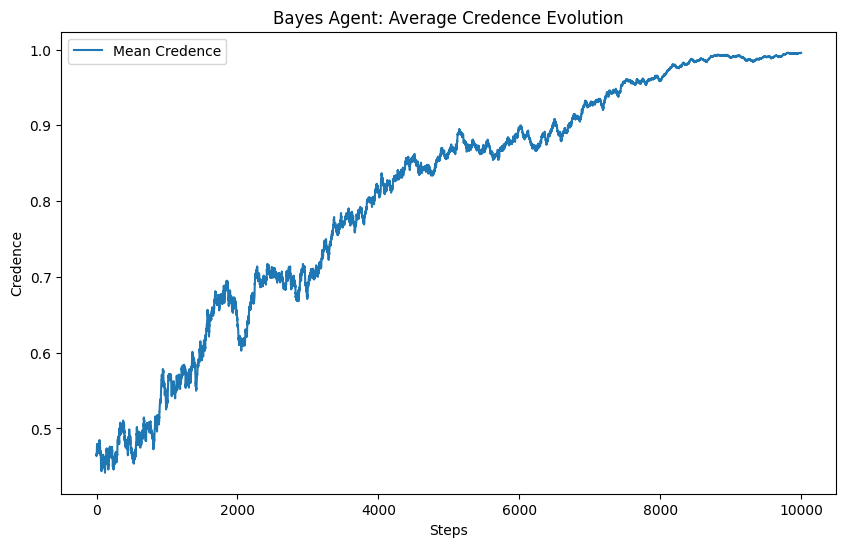

In [4]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [5]:
n_agents = 100
my_network = nx.gnp_random_graph(n_agents, p=0.2, directed=True)

In [6]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

100%|██████████| 10000/10000 [00:02<00:00, 3917.11it/s]


steps:  10000
conclusion:  0.92


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,"[0.9999967312603706, 0.09379100332748372]","[0.9303950959425596, 5.456026479344576e-35]","[0.15201338483459798, 0.6877083488423186]","[0.612096693592278, 0.5095866610718822]","[0.843099176760509, 0.999986521654027]","[0.6212464298022616, 0.8537993246979921]","[0.8346719870205428, 0.7104644752598388]","[0.49985855765360965, 0.2652094719371743]","[0.8016357236634726, 0.11596483130608333]","[8.023934943772129e-09, 0.9136470587012199]",...,"[0.5470757626674477, 1.0]","[0.21995694896270468, 0.001129806616955206]","[0.5138390495503684, 0.4133946695187452]","[0.8981330861700537, 0.39606365166439966]","[0.4523136751714731, 0.0008968463973071944]","[0.38151950200982687, 0.5532610231921649]","[0.7852745070271915, 0.1646498502272724]","[0.9979036815734363, 0.501653199605661]","[0.999999992596214, 0.4944925149985678]","[1.0, 1.0]"
1,"[0.5207432201750302, 0.3594133730838686]","[0.5912287732747679, 0.5670336105987697]","[0.47811412197811565, 0.3958654089846387]","[0.5185764859607593, 0.43761857788942815]","[0.633929105662113, 0.5349450804012733]","[0.48030675924632704, 0.4887095569739161]","[0.5036319915526677, 0.4499724846675048]","[0.5611899513522403, 0.4832573945125939]","[0.4744804137690775, 0.3394547950659289]","[0.503237923531228, 0.5343574392190601]",...,"[0.49045816165283446, 0.42986507438476323]","[0.32948294242346904, 0.4992611156934248]","[0.5233550410683286, 0.4283905790979207]","[0.48519681827630257, 0.4014552270879555]","[0.5076273599727027, 0.3989383500096574]","[0.4384867352351522, 0.5222956995839582]","[0.4050263427242794, 0.37842210210892924]","[0.5183792590949772, 0.5691128635849666]","[0.46485127433680445, 0.4641126610357406]","[0.47551438191248674, 0.47451725486318636]"
2,"[0.5735252599615761, 0.4489773737458022]","[0.5184394382290052, 0.567500692277391]","[0.4545911026677496, 0.45214862614777385]","[0.5028473164356805, 0.5152816823741636]","[0.568234542810439, 0.5977465349881228]","[0.5060904831489877, 0.5680527959366434]","[0.5109114486652586, 0.50773735081894]","[0.45080286173555495, 0.5049306913861923]","[0.5160372290795753, 0.470205588921821]","[0.4888694894686511, 0.5345773857523182]",...,"[0.44736575533221884, 0.508548204708458]","[0.44352088821586744, 0.5461705795816026]","[0.5207227501973456, 0.4310028966774728]","[0.49151798483256215, 0.45950156905299566]","[0.43198690672045825, 0.48355762896919163]","[0.5324055180746452, 0.49428721763438627]","[0.4554376589808913, 0.40950265442215567]","[0.5176650343716653, 0.4639629984618283]","[0.44494252389207056, 0.463070416378109]","[0.5042509875249708, 0.39368440330440746]"


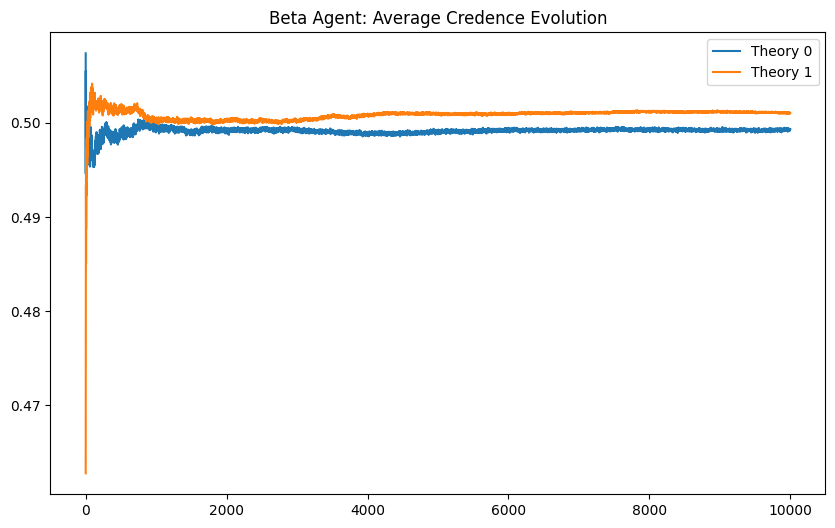

In [7]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

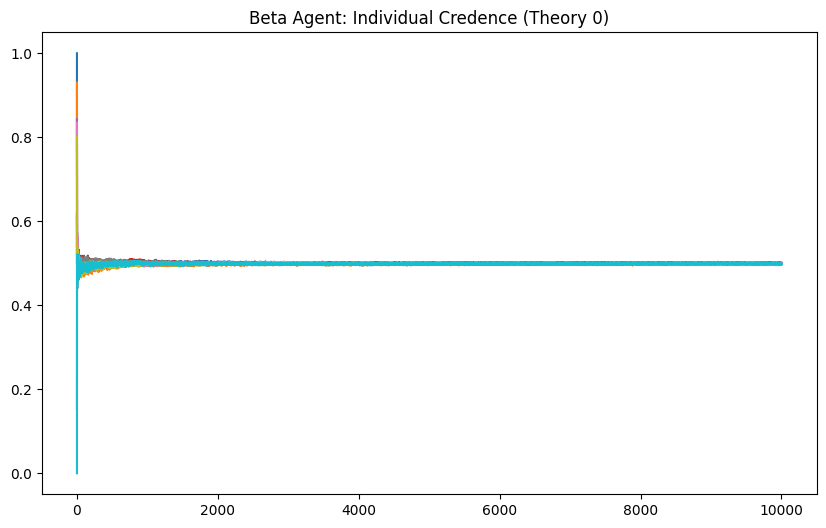

In [8]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()